# Datathon 2026 — Stage 1: Data Preprocessing

**Pipeline tổng quan:**
1. Load & inspect tất cả data files
2. Kiểm tra missing values, duplicates
3. Phân tích outliers trong Revenue
4. Detect structural break (2019)
5. Merge web_traffic vào sales
6. Merge promotions (active promo flag)
7. Export clean dataset cho Stage 2

**Ràng buộc quan trọng:**
- Không dùng Revenue/COGS từ test set làm feature
- Tất cả feature phải từ data được cung cấp
- Web traffic chỉ có đến 31/12/2022 — test period không có

## 0. Setup & Import Libraries

In [1]:
%pip install seaborn pyarrow --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

# Paths
DATA_DIR = r'd:\datathon_2026\train_model\Datathon_2026\data_raw'
OUTPUT_DIR = r'd:\datathon_2026\train_model\Datathon_2026'

print('Libraries loaded successfully!')
print(f'Data directory: {DATA_DIR}')



[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
Libraries loaded successfully!
Data directory: d:\datathon_2026\train_model\Datathon_2026\data_raw


## 1. Load All Data Files

In [2]:
# ── Load core files ──────────────────────────────────────────────
sales       = pd.read_csv(os.path.join(DATA_DIR, 'sales.csv'), parse_dates=['Date'])
sample_sub  = pd.read_csv(os.path.join(DATA_DIR, 'sample_submission.csv'), parse_dates=['Date'])
web_traffic = pd.read_csv(os.path.join(DATA_DIR, 'web_traffic.csv'), parse_dates=['date'])
promotions  = pd.read_csv(os.path.join(DATA_DIR, 'promotions.csv'), parse_dates=['start_date', 'end_date'])
orders      = pd.read_csv(os.path.join(DATA_DIR, 'orders.csv'), parse_dates=['order_date'])
order_items = pd.read_csv(os.path.join(DATA_DIR, 'order_items.csv'), low_memory=False)
products    = pd.read_csv(os.path.join(DATA_DIR, 'products.csv'))
inventory   = pd.read_csv(os.path.join(DATA_DIR, 'inventory.csv'), parse_dates=['snapshot_date'])
returns_df  = pd.read_csv(os.path.join(DATA_DIR, 'returns.csv'), parse_dates=['return_date'])
payments    = pd.read_csv(os.path.join(DATA_DIR, 'payments.csv'))

print('=== File Summary ===')
files = {
    'sales': sales,
    'sample_submission': sample_sub,
    'web_traffic': web_traffic,
    'promotions': promotions,
    'orders': orders,
    'order_items': order_items,
    'products': products,
    'inventory': inventory,
    'returns': returns_df,
    'payments': payments,
}
for name, df in files.items():
    print(f'  {name:20s} → shape: {str(df.shape):15s}')

=== File Summary ===
  sales                → shape: (3833, 3)      
  sample_submission    → shape: (548, 3)       
  web_traffic          → shape: (3652, 7)      
  promotions           → shape: (50, 10)       
  orders               → shape: (646945, 8)    
  order_items          → shape: (714669, 7)    
  products             → shape: (2412, 8)      
  inventory            → shape: (60247, 17)    
  returns              → shape: (39939, 7)     
  payments             → shape: (646945, 4)    


## 2. Inspect Sales (Target Variable)

In [3]:
print('=== SALES.CSV — Train Set ===')
print(f'Date range : {sales.Date.min().date()} → {sales.Date.max().date()}')
print(f'Total rows : {len(sales)}')

# Check for missing dates
full_range = pd.date_range(sales.Date.min(), sales.Date.max(), freq='D')
missing_dates = full_range.difference(sales.Date)
print(f'Missing dates in train : {len(missing_dates)}')

print()
print('=== SAMPLE_SUBMISSION — Test Set ===')
print(f'Date range : {sample_sub.Date.min().date()} → {sample_sub.Date.max().date()}')
print(f'Total rows : {len(sample_sub)}')

test_range = pd.date_range(sample_sub.Date.min(), sample_sub.Date.max(), freq='D')
missing_test = test_range.difference(sample_sub.Date)
print(f'Missing dates in test  : {len(missing_test)}')

print()
print('=== Revenue Statistics ===')
sales[['Revenue', 'COGS']].describe().round(2)

=== SALES.CSV — Train Set ===
Date range : 2012-07-04 → 2022-12-31
Total rows : 3833
Missing dates in train : 0

=== SAMPLE_SUBMISSION — Test Set ===
Date range : 2023-01-01 → 2024-07-01
Total rows : 548
Missing dates in test  : 0

=== Revenue Statistics ===


,Revenue,COGS
count,"3,833.00","3,833.00"
mean,"4,286,584.03","3,695,134.49"
std,"2,624,840.20","2,219,788.77"
min,"279,813.94","236,576.31"
25%,"2,471,088.82","2,150,580.23"
50%,"3,647,303.90","3,161,112.99"
75%,"5,350,877.20","4,637,293.92"
max,"20,905,271.35","16,535,857.67"


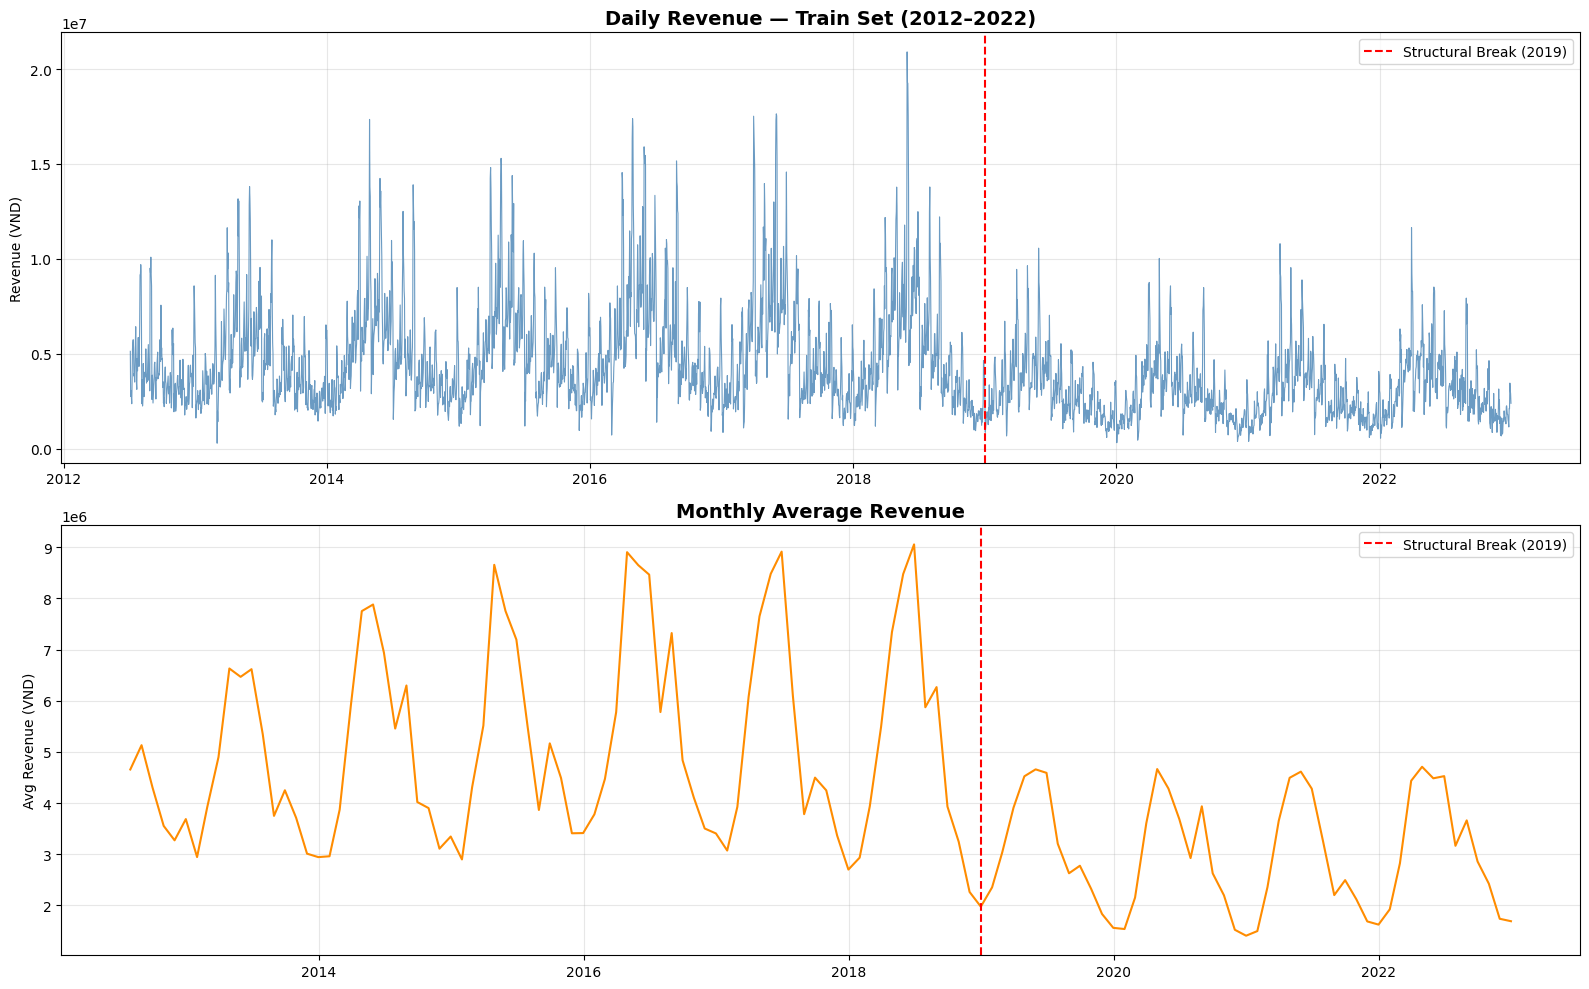

Chart saved: revenue_overview.png


In [4]:
# ── Plot Revenue over time ────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Daily Revenue
axes[0].plot(sales.Date, sales.Revenue, color='steelblue', linewidth=0.8, alpha=0.8)
axes[0].axvline(pd.Timestamp('2019-01-01'), color='red', linestyle='--', linewidth=1.5, label='Structural Break (2019)')
axes[0].set_title('Daily Revenue — Train Set (2012–2022)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Revenue (VND)')
axes[0].legend()
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[0].grid(True, alpha=0.3)

# Monthly avg Revenue
monthly = sales.set_index('Date').resample('ME')['Revenue'].mean()
axes[1].plot(monthly.index, monthly.values, color='darkorange', linewidth=1.5)
axes[1].axvline(pd.Timestamp('2019-01-01'), color='red', linestyle='--', linewidth=1.5, label='Structural Break (2019)')
axes[1].set_title('Monthly Average Revenue', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Avg Revenue (VND)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'revenue_overview.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved: revenue_overview.png')

## 3. Missing Values Analysis

In [5]:
print('=== Missing Values per File ===')
for name, df in files.items():
    null_cols = df.isnull().sum()
    null_cols = null_cols[null_cols > 0]
    if len(null_cols) > 0:
        print(f'\n[{name}]')
        for col, cnt in null_cols.items():
            pct = cnt / len(df) * 100
            print(f'  {col:30s}: {cnt:6d} ({pct:.1f}%)')
    else:
        print(f'[{name}] → No missing values ✓')

=== Missing Values per File ===
[sales] → No missing values ✓
[sample_submission] → No missing values ✓
[web_traffic] → No missing values ✓

[promotions]
  applicable_category           :     40 (80.0%)
[orders] → No missing values ✓

[order_items]
  promo_id                      : 438353 (61.3%)
  promo_id_2                    : 714463 (100.0%)
[products] → No missing values ✓
[inventory] → No missing values ✓
[returns] → No missing values ✓
[payments] → No missing values ✓


## 4. Outlier Detection — Revenue

IQR Outlier Detection (3×IQR):
  Lower bound : -6,168,276
  Upper bound : 13,990,242
  Outliers    : 34 rows (0.89%)

Top 10 extreme Revenue values:
      Date       Revenue          COGS
2018-05-30 20,905,271.35 16,535,857.67
2018-05-31 19,289,944.12 15,561,846.10
2018-06-01 19,245,165.78 15,287,542.60
2017-06-01 17,639,270.88 14,102,311.81
2018-06-02 17,529,108.34 13,707,707.44
2017-06-02 17,528,852.88 14,154,253.77
2017-03-30 17,516,038.82 16,224,964.49
2016-04-28 17,388,183.19 13,978,683.94
2014-04-29 17,347,427.27 13,752,034.86
2017-05-31 17,314,841.86 13,846,685.08


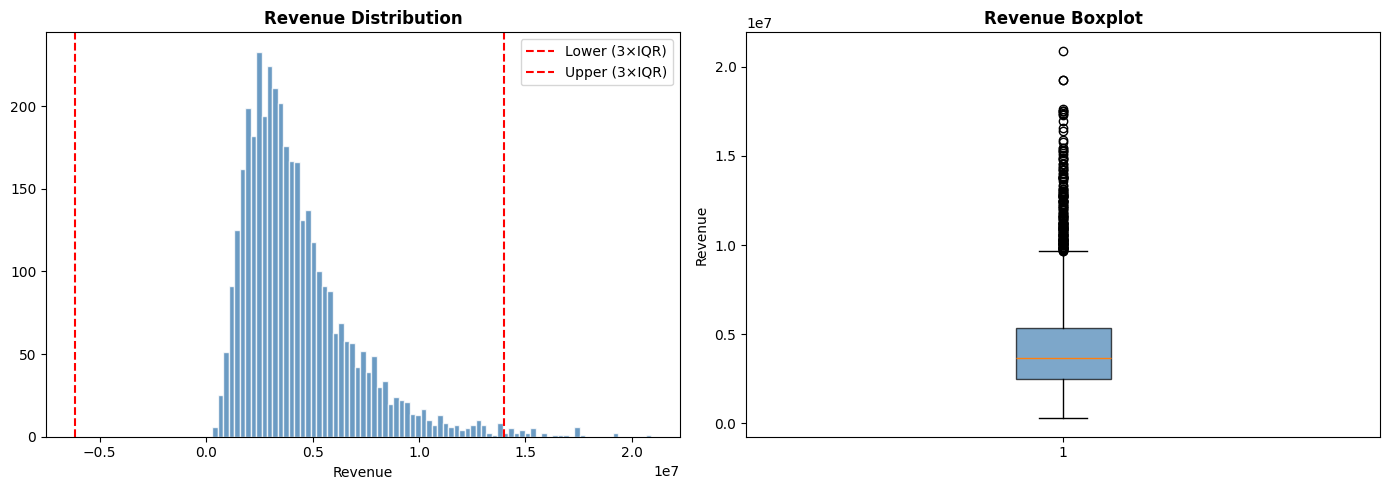

In [6]:
# IQR-based outlier detection
Q1 = sales['Revenue'].quantile(0.25)
Q3 = sales['Revenue'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 3.0 * IQR   # dùng 3x thay vì 1.5x để không cắt quá nhiều
upper_bound = Q3 + 3.0 * IQR

outliers = sales[(sales['Revenue'] < lower_bound) | (sales['Revenue'] > upper_bound)]
print(f'IQR Outlier Detection (3×IQR):')
print(f'  Lower bound : {lower_bound:,.0f}')
print(f'  Upper bound : {upper_bound:,.0f}')
print(f'  Outliers    : {len(outliers)} rows ({len(outliers)/len(sales)*100:.2f}%)')

if len(outliers) > 0:
    print(f'\nTop 10 extreme Revenue values:')
    print(sales.nlargest(10, 'Revenue')[['Date', 'Revenue', 'COGS']].to_string(index=False))

# Plot distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(sales['Revenue'], bins=80, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(lower_bound, color='red', linestyle='--', label=f'Lower (3×IQR)')
axes[0].axvline(upper_bound, color='red', linestyle='--', label=f'Upper (3×IQR)')
axes[0].set_title('Revenue Distribution', fontweight='bold')
axes[0].set_xlabel('Revenue')
axes[0].legend()

axes[1].boxplot(sales['Revenue'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7))
axes[1].set_title('Revenue Boxplot', fontweight='bold')
axes[1].set_ylabel('Revenue')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'revenue_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5. Structural Break Detection (2019)

=== Yearly Revenue Statistics ===
      Mean Revenue  Median Revenue  Std Revenue
year                                           
2012  4,096,673.00    3,666,205.00 1,684,324.00
2013  4,540,190.00    3,927,167.00 2,272,147.00
2014  5,128,345.00    4,538,183.00 2,677,531.00
2015  5,177,901.00    4,612,174.00 2,645,186.00
2016  5,750,384.00    4,934,152.00 3,087,505.00
2017  5,236,067.00    4,375,381.00 3,075,067.00
2018  5,068,829.00    4,317,415.00 3,168,626.00
2019  3,114,524.00    2,811,324.00 1,642,734.00
2020  2,881,181.00    2,596,347.00 1,637,312.00
2021  2,857,643.00    2,480,974.00 1,644,091.00
2022  3,204,791.00    2,945,502.00 1,676,108.00

=== Year-over-Year Change ===
      Mean Revenue  YoY Change (%)
year                              
2012  4,096,673.00             NaN
2013  4,540,190.00           10.80
2014  5,128,345.00           13.00
2015  5,177,901.00            1.00
2016  5,750,384.00           11.10
2017  5,236,067.00           -8.90
2018  5,068,829.00           -3

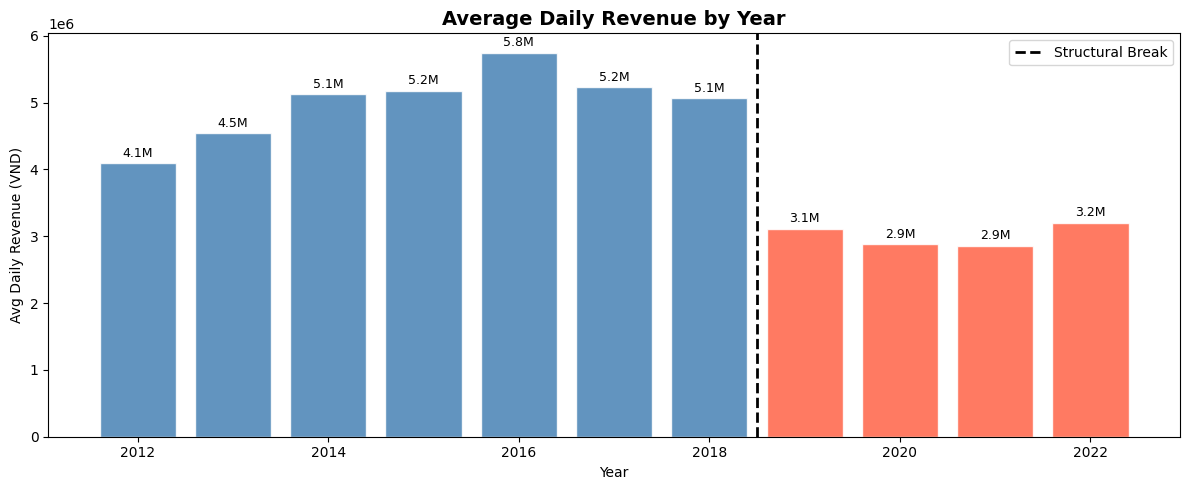


→ Structural break rõ ràng tại 2019: Revenue giảm ~40% so với 2018


In [7]:
# Yearly statistics để confirm break point
sales['year'] = sales['Date'].dt.year
yearly_stats = sales.groupby('year')['Revenue'].agg(['mean', 'median', 'std']).round(0)
yearly_stats.columns = ['Mean Revenue', 'Median Revenue', 'Std Revenue']

print('=== Yearly Revenue Statistics ===')
print(yearly_stats.to_string())

# Tính % thay đổi YoY
yearly_stats['YoY Change (%)'] = yearly_stats['Mean Revenue'].pct_change() * 100
print()
print('=== Year-over-Year Change ===')
print(yearly_stats[['Mean Revenue', 'YoY Change (%)']].round(1).to_string())

# Visualize
fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(yearly_stats.index, yearly_stats['Mean Revenue'],
              color=['steelblue' if y < 2019 else 'tomato' for y in yearly_stats.index],
              edgecolor='white', alpha=0.85)
ax.axvline(2018.5, color='black', linestyle='--', linewidth=2, label='Structural Break')
ax.set_title('Average Daily Revenue by Year', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Avg Daily Revenue (VND)')
ax.legend()

# Annotate bars
for bar, val in zip(bars, yearly_stats['Mean Revenue']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50000,
            f'{val/1e6:.1f}M', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'yearly_revenue.png'), dpi=150, bbox_inches='tight')
plt.show()
print('\n→ Structural break rõ ràng tại 2019: Revenue giảm ~40% so với 2018')

## 6. Seasonality Analysis

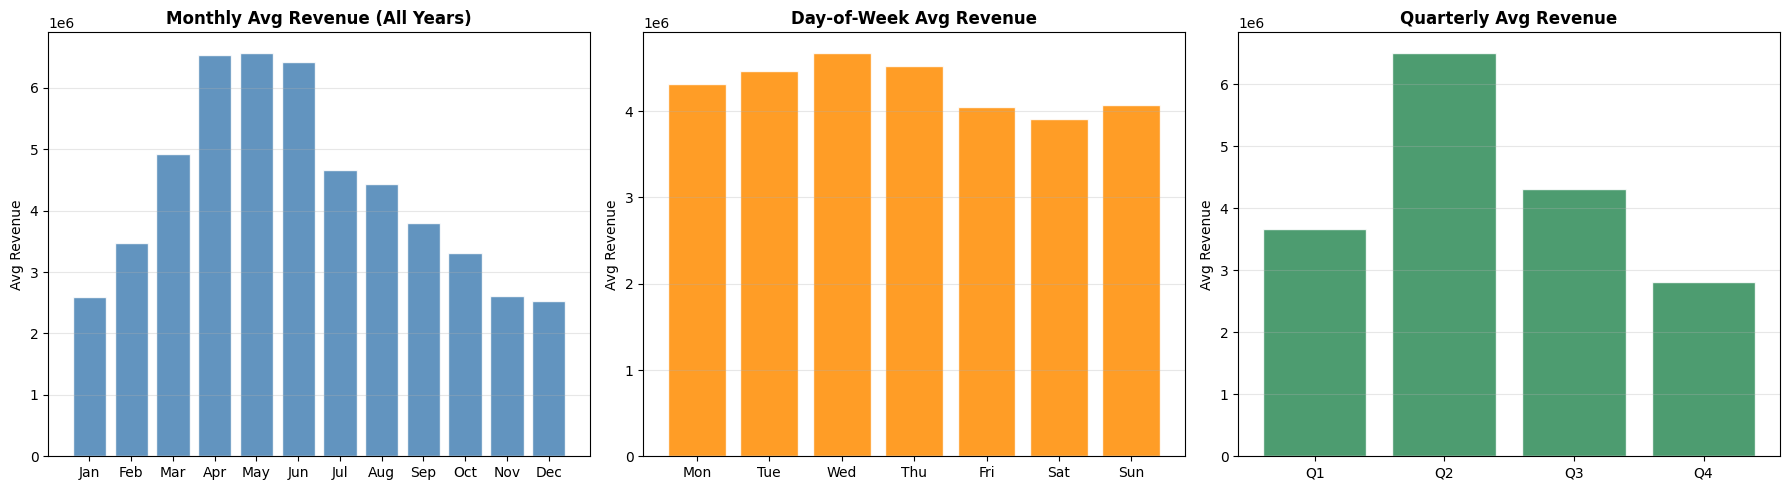

Key Seasonality Insights:
  Peak months : Apr–Jun (avg 6.5M)
  Low months  : Nov–Jan (avg 2.6M)
  Peak DOW    : Wed (avg 4.7M)
  Low DOW     : Sat (avg 3.9M)


In [8]:
sales['month'] = sales['Date'].dt.month
sales['day_of_week'] = sales['Date'].dt.dayofweek  # 0=Mon, 6=Sun
sales['quarter'] = sales['Date'].dt.quarter

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Monthly seasonality
monthly_avg = sales.groupby('month')['Revenue'].mean()
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
axes[0].bar(range(1, 13), monthly_avg.values, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(month_names)
axes[0].set_title('Monthly Avg Revenue (All Years)', fontweight='bold')
axes[0].set_ylabel('Avg Revenue')
axes[0].grid(True, alpha=0.3, axis='y')

# Day of week
dow_avg = sales.groupby('day_of_week')['Revenue'].mean()
dow_names = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
axes[1].bar(range(7), dow_avg.values, color='darkorange', edgecolor='white', alpha=0.85)
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(dow_names)
axes[1].set_title('Day-of-Week Avg Revenue', fontweight='bold')
axes[1].set_ylabel('Avg Revenue')
axes[1].grid(True, alpha=0.3, axis='y')

# Quarter
q_avg = sales.groupby('quarter')['Revenue'].mean()
axes[2].bar(['Q1','Q2','Q3','Q4'], q_avg.values, color='seagreen', edgecolor='white', alpha=0.85)
axes[2].set_title('Quarterly Avg Revenue', fontweight='bold')
axes[2].set_ylabel('Avg Revenue')
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'seasonality.png'), dpi=150, bbox_inches='tight')
plt.show()

print('Key Seasonality Insights:')
print(f'  Peak months : Apr–Jun (avg {monthly_avg[[4,5,6]].mean()/1e6:.1f}M)')
print(f'  Low months  : Nov–Jan (avg {monthly_avg[[1,11,12]].mean()/1e6:.1f}M)')
print(f'  Peak DOW    : {dow_names[dow_avg.idxmax()]} (avg {dow_avg.max()/1e6:.1f}M)')
print(f'  Low DOW     : {dow_names[dow_avg.idxmin()]} (avg {dow_avg.min()/1e6:.1f}M)')

## 7. Web Traffic — Date Coverage Check

In [9]:
print('=== WEB TRAFFIC DATE COVERAGE ===')
print(f'Train period : {sales.Date.min().date()} → {sales.Date.max().date()}')
print(f'Web traffic  : {web_traffic.date.min().date()} → {web_traffic.date.max().date()}')
print(f'Test period  : {sample_sub.Date.min().date()} → {sample_sub.Date.max().date()}')
print()
print('⚠️  Web traffic KHÔNG có dữ liệu cho test period (2023-2024)')
print('   → Sẽ dùng web_traffic làm feature trong train, nhưng KHÔNG thể dùng trực tiếp cho test')
print('   → Strategy: aggregate web_traffic theo ngày rồi dùng lag/rolling features')

# Pivot web_traffic: tổng sessions/page_views theo ngày (gộp tất cả sources)
daily_web = web_traffic.groupby('date').agg(
    total_sessions=('sessions', 'sum'),
    total_visitors=('unique_visitors', 'sum'),
    total_page_views=('page_views', 'sum'),
    avg_bounce_rate=('bounce_rate', 'mean'),
    avg_session_duration=('avg_session_duration_sec', 'mean')
).reset_index()

print(f'\nDaily web traffic shape: {daily_web.shape}')
print(f'Date range: {daily_web.date.min().date()} → {daily_web.date.max().date()}')
daily_web.head(3)

=== WEB TRAFFIC DATE COVERAGE ===
Train period : 2012-07-04 → 2022-12-31
Web traffic  : 2013-01-01 → 2022-12-31
Test period  : 2023-01-01 → 2024-07-01

⚠️  Web traffic KHÔNG có dữ liệu cho test period (2023-2024)
   → Sẽ dùng web_traffic làm feature trong train, nhưng KHÔNG thể dùng trực tiếp cho test
   → Strategy: aggregate web_traffic theo ngày rồi dùng lag/rolling features

Daily web traffic shape: (3652, 6)
Date range: 2013-01-01 → 2022-12-31


,date,total_sessions,total_visitors,total_page_views,avg_bounce_rate,avg_session_duration
0,2013-01-01,9760,7253,39093,0.01,102.90
1,2013-01-02,10456,8151,47611,0.00,120.50
2,2013-01-03,10076,7458,36963,0.00,263.60


## 8. Promotions — Active Promo Flag

In [10]:
print('=== PROMOTIONS OVERVIEW ===')
print(f'Total promos : {len(promotions)}')
print(f'Date range   : {promotions.start_date.min().date()} → {promotions.end_date.max().date()}')
print(f'Promo types  : {promotions.promo_type.value_counts().to_dict()}')
print(f'Discount range: {promotions.discount_value.min()}% → {promotions.discount_value.max()}%')
print()

# Build daily promo features — tạo flag cho mỗi ngày trong train+test
# Gộp train + test dates
all_dates = pd.DataFrame({
    'date': pd.date_range(
        start=sales['Date'].min(),
        end=sample_sub['Date'].max(),
        freq='D'
    )
})

# Với mỗi ngày, đếm số promo đang active và tổng discount_value
def get_promo_features(date_val):
    active = promotions[
        (promotions['start_date'] <= date_val) &
        (promotions['end_date'] >= date_val)
    ]
    return pd.Series({
        'n_active_promos': len(active),
        'avg_discount_value': active['discount_value'].mean() if len(active) > 0 else 0.0,
        'max_discount_value': active['discount_value'].max() if len(active) > 0 else 0.0,
        'has_promo': int(len(active) > 0)
    })

print('Building daily promo features (this may take ~30s)...')
promo_features = all_dates['date'].apply(get_promo_features)
daily_promo = pd.concat([all_dates, promo_features], axis=1)

print(f'Daily promo features shape: {daily_promo.shape}')
print(f'Days with active promo: {daily_promo["has_promo"].sum()} ({daily_promo["has_promo"].mean()*100:.1f}%)')
print()
daily_promo[daily_promo['has_promo'] == 1].head(5)

=== PROMOTIONS OVERVIEW ===
Total promos : 50
Date range   : 2013-01-31 → 2022-12-31
Promo types  : {'percentage': 45, 'fixed': 5}
Discount range: 10.0% → 50.0%

Building daily promo features (this may take ~30s)...
Daily promo features shape: (4381, 5)
Days with active promo: 1707.0 (39.0%)



,date,n_active_promos,avg_discount_value,max_discount_value,has_promo
211,2013-01-31,1.00,15.00,15.00,1.00
212,2013-02-01,1.00,15.00,15.00,1.00
213,2013-02-02,1.00,15.00,15.00,1.00
214,2013-02-03,1.00,15.00,15.00,1.00
215,2013-02-04,1.00,15.00,15.00,1.00


## 9. Daily Orders Summary

In [11]:
# Aggregate orders per day — chỉ dùng cho TRAIN (không có order data cho test)
daily_orders = orders.groupby('order_date').agg(
    n_orders=('order_id', 'count'),
    n_cancelled=('order_status', lambda x: (x == 'cancelled').sum()),
    n_returned=('order_status', lambda x: (x == 'returned').sum()),
    mobile_orders=('device_type', lambda x: (x == 'mobile').sum()),
    organic_orders=('order_source', lambda x: (x == 'organic_search').sum()),
).reset_index()

daily_orders['cancel_rate'] = daily_orders['n_cancelled'] / daily_orders['n_orders']
daily_orders['return_rate'] = daily_orders['n_returned'] / daily_orders['n_orders']
daily_orders['mobile_rate'] = daily_orders['mobile_orders'] / daily_orders['n_orders']
daily_orders['organic_rate'] = daily_orders['organic_orders'] / daily_orders['n_orders']

print(f'Daily orders shape: {daily_orders.shape}')
print(f'Date range: {daily_orders.order_date.min().date()} → {daily_orders.order_date.max().date()}')
daily_orders.head(3)

Daily orders shape: (3833, 10)
Date range: 2012-07-04 → 2022-12-31


,order_date,n_orders,n_cancelled,n_returned,mobile_orders,organic_orders,cancel_rate,return_rate,mobile_rate,organic_rate
0,2012-07-04,162,9,11,69,52,0.06,0.07,0.43,0.32
1,2012-07-05,97,9,5,38,26,0.09,0.05,0.39,0.27
2,2012-07-06,93,11,7,42,28,0.12,0.08,0.45,0.30


## 10. Build Master Dataset (Train + Test)

In [12]:
# ── Tạo base dataframe: ALL dates (train + test) ─────────────────
train = sales[['Date', 'Revenue', 'COGS']].copy()
train.columns = ['date', 'Revenue', 'COGS']
train['split'] = 'train'

test = sample_sub[['Date']].copy()
test.columns = ['date']
test['Revenue'] = np.nan   # placeholder — cần dự báo
test['COGS'] = np.nan      # placeholder — cần dự báo
test['split'] = 'test'

master = pd.concat([train, test], ignore_index=True)
master = master.sort_values('date').reset_index(drop=True)

print(f'Master dataset shape : {master.shape}')
print(f'Train rows           : {(master.split=="train").sum()}')
print(f'Test rows            : {(master.split=="test").sum()}')
print(f'Date range           : {master.date.min().date()} → {master.date.max().date()}')
print()

# ── Merge web_traffic (forward-fill cho test period) ─────────────
master = master.merge(daily_web.rename(columns={'date': 'date'}),
                      on='date', how='left')

# Forward-fill web traffic cho test period bằng rolling mean của 30 ngày cuối
web_cols = ['total_sessions', 'total_visitors', 'total_page_views',
            'avg_bounce_rate', 'avg_session_duration']
for col in web_cols:
    # Fill NaN trong test bằng giá trị trung bình 30 ngày cuối của train
    last30_mean = master.loc[master['split'] == 'train', col].tail(30).mean()
    master[col] = master[col].fillna(last30_mean)

# ── Merge daily_promo ─────────────────────────────────────────────
master = master.merge(daily_promo.rename(columns={'date': 'date'}),
                      on='date', how='left')

# ── Merge daily_orders (chỉ có cho train) ────────────────────────
master = master.merge(daily_orders.rename(columns={'order_date': 'date'}),
                      on='date', how='left')

# Các order columns sẽ NaN ở test — đó là đúng, sẽ xử lý bằng lag ở Stage 2

print(f'Master after merge shape: {master.shape}')
print(f'Columns: {list(master.columns)}')
master.head(3)

Master dataset shape : (4381, 4)
Train rows           : 3833
Test rows            : 548
Date range           : 2012-07-04 → 2024-07-01

Master after merge shape: (4381, 22)
Columns: ['date', 'Revenue', 'COGS', 'split', 'total_sessions', 'total_visitors', 'total_page_views', 'avg_bounce_rate', 'avg_session_duration', 'n_active_promos', 'avg_discount_value', 'max_discount_value', 'has_promo', 'n_orders', 'n_cancelled', 'n_returned', 'mobile_orders', 'organic_orders', 'cancel_rate', 'return_rate', 'mobile_rate', 'organic_rate']


,date,Revenue,COGS,split,total_sessions,total_visitors,total_page_views,avg_bounce_rate,avg_session_duration,n_active_promos,avg_discount_value,max_discount_value,has_promo,n_orders,n_cancelled,n_returned,mobile_orders,organic_orders,cancel_rate,return_rate,mobile_rate,organic_rate
0,2012-07-04,"5,123,547.94","3,982,991.19",train,"20,692.97","15,857.83","90,341.73",0.00,191.01,0.00,0.00,0.00,0.00,162.00,9.00,11.00,69.00,52.00,0.06,0.07,0.43,0.32
1,2012-07-05,"2,751,773.45","2,150,580.23",train,"20,692.97","15,857.83","90,341.73",0.00,191.01,0.00,0.00,0.00,0.00,97.00,9.00,5.00,38.00,26.00,0.09,0.05,0.39,0.27
2,2012-07-06,"3,054,029.42","2,517,632.84",train,"20,692.97","15,857.83","90,341.73",0.00,191.01,0.00,0.00,0.00,0.00,93.00,11.00,7.00,42.00,28.00,0.12,0.08,0.45,0.30


## 11. Data Quality Check — Final

In [13]:
print('=== FINAL DATA QUALITY REPORT ===')
print(f'Shape: {master.shape}')
print()

# Missing values in train (excluding Revenue/COGS in test)
train_master = master[master['split'] == 'train'].copy()
test_master  = master[master['split'] == 'test'].copy()

print('--- Train set missing values ---')
null_train = train_master.isnull().sum()
null_train = null_train[null_train > 0]
if len(null_train) > 0:
    print(null_train.to_string())
else:
    print('  No missing values in train ✓')

print()
print('--- Test set missing values (Revenue/COGS expected) ---')
null_test = test_master.drop(columns=['Revenue', 'COGS']).isnull().sum()
null_test = null_test[null_test > 0]
if len(null_test) > 0:
    print(null_test.to_string())
else:
    print('  No unexpected missing values in test ✓')

print()
print('--- Duplicate dates check ---')
dup_train = train_master['date'].duplicated().sum()
dup_test  = test_master['date'].duplicated().sum()
print(f'  Train duplicates: {dup_train}')
print(f'  Test duplicates : {dup_test}')

print()
print('--- Revenue sanity check (train) ---')
neg_rev = (train_master['Revenue'] < 0).sum()
zero_rev = (train_master['Revenue'] == 0).sum()
print(f'  Negative Revenue : {neg_rev}')
print(f'  Zero Revenue     : {zero_rev}')
print(f'  Min Revenue      : {train_master["Revenue"].min():,.0f}')
print(f'  Max Revenue      : {train_master["Revenue"].max():,.0f}')

=== FINAL DATA QUALITY REPORT ===
Shape: (4381, 22)

--- Train set missing values ---
  No missing values in train ✓

--- Test set missing values (Revenue/COGS expected) ---
n_orders          548
n_cancelled       548
n_returned        548
mobile_orders     548
organic_orders    548
cancel_rate       548
return_rate       548
mobile_rate       548
organic_rate      548

--- Duplicate dates check ---
  Train duplicates: 0
  Test duplicates : 0

--- Revenue sanity check (train) ---
  Negative Revenue : 0
  Zero Revenue     : 0
  Min Revenue      : 279,814
  Max Revenue      : 20,905,271


## 12. Export Clean Dataset

In [14]:
# Export master dataset for Stage 2 (dùng CSV để tránh pyarrow version conflict)
csv_path = os.path.join(OUTPUT_DIR, 'master_clean.csv')
master.to_csv(csv_path, index=False)
print(f'✓ Master dataset saved → {csv_path}')
print(f'  Shape : {master.shape}')
print(f'  Size  : {os.path.getsize(csv_path)/1024:.1f} KB')

print()
print('=== STAGE 1 COMPLETE ===')
print(f'Output columns: {list(master.columns)}')
print()
print('Summary của Master Dataset:')
print(master.groupby('split').agg(
    rows=('date','count'),
    date_from=('date','min'),
    date_to=('date','max')
).to_string())


✓ Master dataset saved → d:\datathon_2026\train_model\Datathon_2026\master_clean.csv
  Shape : (4381, 22)
  Size  : 814.7 KB

=== STAGE 1 COMPLETE ===
Output columns: ['date', 'Revenue', 'COGS', 'split', 'total_sessions', 'total_visitors', 'total_page_views', 'avg_bounce_rate', 'avg_session_duration', 'n_active_promos', 'avg_discount_value', 'max_discount_value', 'has_promo', 'n_orders', 'n_cancelled', 'n_returned', 'mobile_orders', 'organic_orders', 'cancel_rate', 'return_rate', 'mobile_rate', 'organic_rate']

Summary của Master Dataset:
       rows  date_from    date_to
split                            
test    548 2023-01-01 2024-07-01
train  3833 2012-07-04 2022-12-31


---
## Stage 1 Summary

| Item | Result |
|------|--------|
| Train rows | 3,833 ngày |
| Test rows | 548 ngày |
| Missing dates | 0 |
| Structural break | 2019 (Revenue giảm ~40%) |
| Peak months | Tháng 4–6 |
| Web traffic available | Train only (2013–2022) |
| Promotions | 50 campaigns, 2013–2022 |
| Output | `master_clean.parquet` |

**→ Stage 2: Feature Engineering (lag, rolling, Fourier, calendar features)**